<a href="https://colab.research.google.com/github/roshika1235/Data_Analysis_Tasks/blob/main/ECOMMERCE_TASK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Performing Data Cleaning, EDA process on E-commerence

## IMPORTING ALL NECESSARY LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## READ ALL 3 DATASETS

In [ ]:
df1=pd.read_csv('/content/customers.csv')
df2=pd.read_csv("/content/orders.csv")
df3=pd.read_csv("/content/products.csv")

## MERGE THEM AS ONE

In [ ]:
df4=df2.merge(df1,on='customer_id')
df=df4.merge(df3,on='product_id')
df


,order_id,customer_id,product_id,order_date,city,quantity,customer_name,signup_date,product_name,category,price
0,1,101,201,2024-01-05,Hyderabad,1,Ravi,2023-11-10,Laptop,Electronics,70000
1,2,102,202,2024-01-06,Bangalore,2,Sneha,2023-12-01,Mobile,Electronics,20000
2,3,103,203,2024-01-10,Chennai,1,Amit,2023-12-15,Tablet,Electronics,15000
3,4,101,202,2024-02-12,Hyderabad,1,Ravi,2023-11-10,Mobile,Electronics,20000
4,5,104,204,2024-02-18,Bangalore,3,Pooja,2024-01-05,Shoes,Fashion,3000
5,6,105,201,2024-03-05,Chennai,1,Kiran,2024-01-20,Laptop,Electronics,70000
6,7,102,203,2024-03-15,Bangalore,1,Sneha,2023-12-01,Tablet,Electronics,15000
7,8,106,205,2024-04-02,Hyderabad,2,Arjun,2024-02-02,Watch,Fashion,5000
8,9,107,202,2024-04-10,Chennai,1,Divya,2024-02-15,Mobile,Electronics,20000
9,10,108,204,2024-04-18,Bangalore,2,Rahul,2024-03-01,Shoes,Fashion,3000


## PERFORMING DATA CLEANING AND EXPLORING THE DATA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       20 non-null     int64 
 1   customer_id    20 non-null     int64 
 2   product_id     20 non-null     int64 
 3   order_date     20 non-null     object
 4   city           20 non-null     object
 5   quantity       20 non-null     int64 
 6   customer_name  20 non-null     object
 7   signup_date    20 non-null     object
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
product_id,0
order_date,0
city,0
quantity,0
customer_name,0
signup_date,0
product_name,0
category,0


## CHANGING COLUMNS DATATYPE ACCORDINGLY

In [ ]:
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["order_date"]=pd.to_datetime(df["order_date"])
df

,order_id,customer_id,product_id,order_date,city,quantity,customer_name,signup_date,product_name,category,price
0,1,101,201,2024-01-05,Hyderabad,1,Ravi,2023-11-10,Laptop,Electronics,70000
1,2,102,202,2024-01-06,Bangalore,2,Sneha,2023-12-01,Mobile,Electronics,20000
2,3,103,203,2024-01-10,Chennai,1,Amit,2023-12-15,Tablet,Electronics,15000
3,4,101,202,2024-02-12,Hyderabad,1,Ravi,2023-11-10,Mobile,Electronics,20000
4,5,104,204,2024-02-18,Bangalore,3,Pooja,2024-01-05,Shoes,Fashion,3000
5,6,105,201,2024-03-05,Chennai,1,Kiran,2024-01-20,Laptop,Electronics,70000
6,7,102,203,2024-03-15,Bangalore,1,Sneha,2023-12-01,Tablet,Electronics,15000
7,8,106,205,2024-04-02,Hyderabad,2,Arjun,2024-02-02,Watch,Fashion,5000
8,9,107,202,2024-04-10,Chennai,1,Divya,2024-02-15,Mobile,Electronics,20000
9,10,108,204,2024-04-18,Bangalore,2,Rahul,2024-03-01,Shoes,Fashion,3000


## PERFORMING DIMENSIONALITY REDUCTION FOR BETTER ANALYSIS

In [ ]:
df["Total_sales"]=df["quantity"]*df["price"]
df.head()

,order_id,customer_id,product_id,order_date,city,quantity,customer_name,signup_date,product_name,category,price,Total_sales
0,1,101,201,2024-01-05,Hyderabad,1,Ravi,2023-11-10,Laptop,Electronics,70000,70000
1,2,102,202,2024-01-06,Bangalore,2,Sneha,2023-12-01,Mobile,Electronics,20000,40000
2,3,103,203,2024-01-10,Chennai,1,Amit,2023-12-15,Tablet,Electronics,15000,15000
3,4,101,202,2024-02-12,Hyderabad,1,Ravi,2023-11-10,Mobile,Electronics,20000,20000
4,5,104,204,2024-02-18,Bangalore,3,Pooja,2024-01-05,Shoes,Fashion,3000,9000


Text(0.5, 1.0, 'revenue chart')

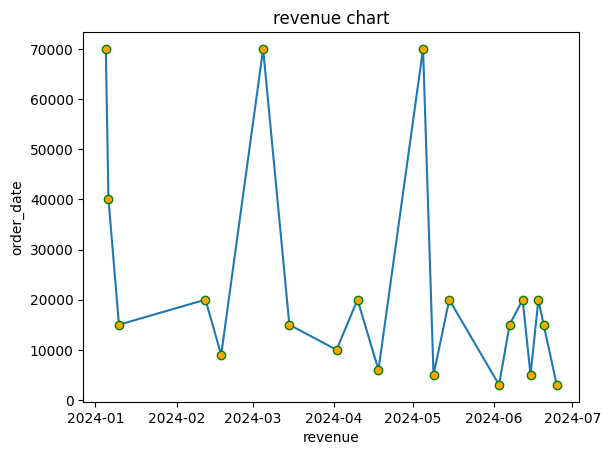

In [ ]:
#revenue
revenue=df.groupby("order_date")["Total_sales"].sum().sort_values(ascending=False)
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(df["order_date"],df["Total_sales"],marker='o',mfc="orange",mec="green")
plt.xlabel("revenue")
plt.ylabel("order_date")
plt.title("revenue chart")


## THE ABOVE PLOT TELLS HOW TOTAL SALES WHERE IMPACTING YEARWISE, BY CHECKING HOW MANY ORDERS IT IS TAKING EVERY MONTH

**revenue is less in the past 2 months june,july**

Text(0.5, 1.0, 'revenue chart  by city')

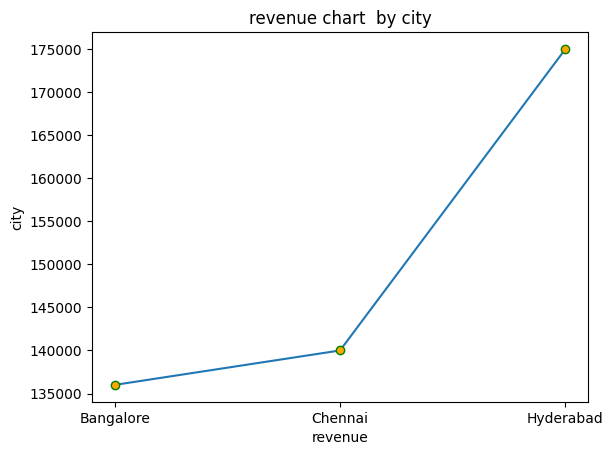

In [ ]:
city_1=df.groupby("city")["Total_sales"].sum().sort_values()
city_1=pd.DataFrame(city_1).reset_index()
plt.plot(city_1["city"],city_1["Total_sales"],marker='o',mfc="orange",mec="green")
plt.xlabel("revenue")
plt.ylabel("city")
plt.title("revenue chart  by city")

## BANGALORE CITY IS HAVING LOW REVENUE

Text(0.5, 1.0, 'revenue chart  by category')

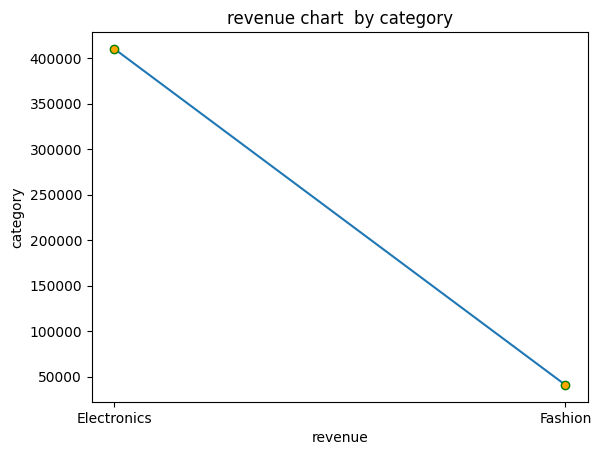

In [ ]:
category_1=df.groupby("category")["Total_sales"].sum()
category_1=pd.DataFrame(category_1).reset_index()
plt.plot(category_1["category"],category_1["Total_sales"],marker='o',mfc="orange",mec="green")
plt.xlabel("revenue")
plt.ylabel("category")
plt.title("revenue chart  by category")

## category based revenue drop , FASHION sector having low sales

In [ ]:
#count customers based on order_id
cust_order_count=df.groupby("customer_id")["order_id"].count()


**most of the customer ordering one product**

Text(0.5, 1.0, 'revenue chart  by city')

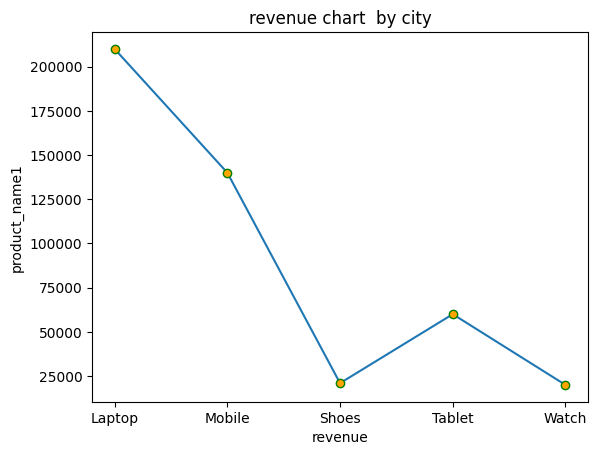

In [ ]:
product_name1=df.groupby("product_name")["Total_sales"].sum()
product_name1=pd.DataFrame(product_name1).reset_index()
plt.plot(product_name1["product_name"],product_name1["Total_sales"],marker='o',mfc="orange",mec="green")
plt.xlabel("revenue")
plt.ylabel("product_name1")
plt.title("revenue chart  by city")

Text(0.5, 1.0, 'revenue chart  by product')

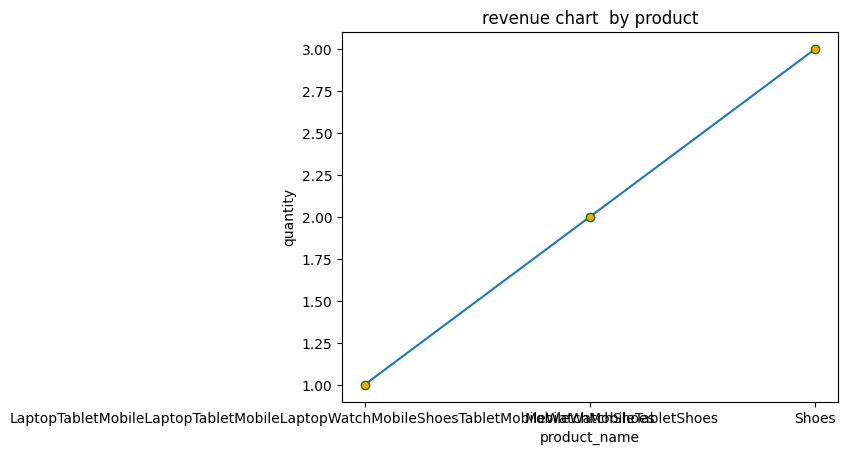

In [ ]:
r=df.groupby("quantity")["product_name"].sum()
r=pd.DataFrame(r).reset_index()
plt.plot(r["product_name"],r["quantity"],marker='o',mfc="orange",mec="green")
plt.xlabel("product_name")
plt.ylabel("quantity")
plt.title("revenue chart  by product")

**insights**:
- revenue is dropped in the month of mid may to july
- in banglore contributed more in revenue drop
- fashion category has more revenue drop (less)
- repeated customers ordered less
- shoes and watch sales declined signficantly

**Recommendation**:
- marketing should be done in bangolore
- provide discount
- coupons,loyalty programs.

**revenue is very less in shoes and watch**